**The goal was to analyze model interpretability and fairness using the Titanic dataset.**

In [ ]:
!pip install shap

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data = df[['Pclass','Sex','Age','Fare','Survived']]

data = data.dropna()

data['Sex'] = data['Sex'].map({
    'male':0,
    'female':1
})

data.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.7762237762237763


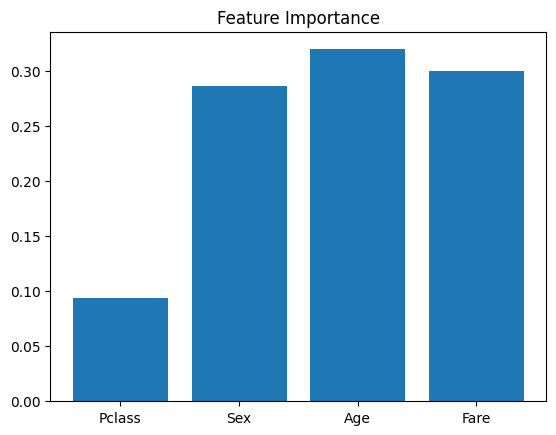

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)

plt.title("Feature Importance")
plt.show()

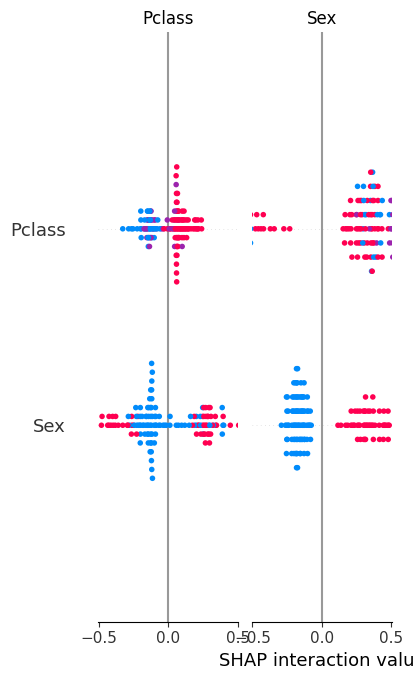

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0][:, 1],
    X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

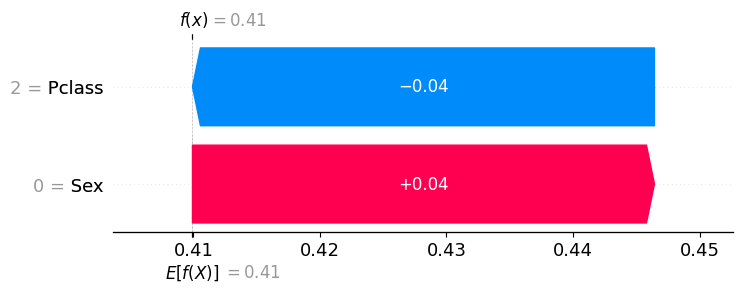

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],  # SHAP values for the first instance, class 1
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0].values,
        feature_names=X_test.columns.tolist()
    )
)

In [ ]:
male = X_test['Sex'] == 0
female = X_test['Sex'] == 1

from sklearn.metrics import accuracy_score

male_acc = accuracy_score(
    y_test[male],
    pred[male]
)

female_acc = accuracy_score(
    y_test[female],
    pred[female]
)

print("Male Accuracy:", male_acc)
print("Female Accuracy:", female_acc)

Male Accuracy: 0.7752808988764045
Female Accuracy: 0.7777777777777778


**conclusion**

The model achieved good predictive performance and SHAP provided transparent explanations. Bias analysis highlighted the importance of evaluating fairness before deploying AI systems.